### Uppgift 0 - Uppvärmning


In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
directory_data = "../data"

athletes = pd.read_csv(f"{directory_data}/athlete_events.csv")
regions = pd.read_csv(f"{directory_data}/noc_regions.csv")

Merge Athlete data with NOC

In [7]:
merged = pd.merge(athletes, regions, on="NOC", how="outer")

Seeing how the first rows look after merging the 2 data files

In [8]:
merged.head()

,ID,Name,Sex,Age,Height,Weight,Team,NOC,Games,Year,Season,City,Sport,Event,Medal,region,notes
0,502.0,Ahmad Shah Abouwi,M,NaN,NaN,NaN,Afghanistan,AFG,1956 Summer,1956.0,Summer,Melbourne,Hockey,Hockey Men's Hockey,NaN,Afghanistan,NaN
1,1076.0,Jammal-ud-Din Affendi,M,28.0,NaN,NaN,Afghanistan,AFG,1936 Summer,1936.0,Summer,Berlin,Hockey,Hockey Men's Hockey,NaN,Afghanistan,NaN
2,1101.0,Mohammad Anwar Afzal,M,NaN,NaN,NaN,Afghanistan,AFG,1948 Summer,1948.0,Summer,London,Football,Football Men's Football,NaN,Afghanistan,NaN
3,1745.0,Mohammad Aktar,M,17.0,156.0,48.0,Afghanistan,AFG,1980 Summer,1980.0,Summer,Moskva,Wrestling,"Wrestling Men's Light-Flyweight, Freestyle",NaN,Afghanistan,NaN
4,4628.0,Mohammad Daoud Anwary,M,22.0,NaN,NaN,Afghanistan,AFG,1964 Summer,1964.0,Summer,Tokyo,Wrestling,"Wrestling Men's Bantamweight, Freestyle",NaN,Afghanistan,NaN


#### a - Hur många länder är med i datan?

In [22]:
merged['region'].shape

(271117,)

Svar 271 117 stycker länder ungefär! Vissa rader i denna kolumnen innehåller olika delar av samma land, samt är det vissa rader som inte har ett landsnamn under alls under region utan det står tex unknown eller refugee olympic team.

#### b - Vilka länder är med?

In [20]:
merged['region'].unique()

array(['Afghanistan', 'Curacao', 'Albania', 'Algeria', 'Andorra',
       'Angola', 'Antigua', 'Australia', 'Argentina', 'Armenia', 'Aruba',
       'American Samoa', 'Austria', 'Azerbaijan', 'Bahamas', 'Bangladesh',
       'Barbados', 'Burundi', 'Belgium', 'Benin', 'Bermuda', 'Bhutan',
       'Bosnia and Herzegovina', 'Belize', 'Belarus', 'Czech Republic',
       'Boliva', 'Botswana', 'Brazil', 'Bahrain', 'Brunei', 'Bulgaria',
       'Burkina Faso', 'Central African Republic', 'Cambodia', 'Canada',
       'Cayman Islands', 'Republic of Congo', 'Chad', 'Chile', 'China',
       'Ivory Coast', 'Cameroon', 'Democratic Republic of the Congo',
       'Cook Islands', 'Colombia', 'Comoros', 'Cape Verde', 'Costa Rica',
       'Croatia', 'Greece', 'Cuba', 'Cyprus', 'Denmark', 'Djibouti',
       'Dominica', 'Dominican Republic', 'Ecuador', 'Egypt', 'Eritrea',
       'El Salvador', 'Spain', 'Estonia', 'Ethiopia', 'Russia', 'Fiji',
       'Finland', 'France', 'Germany', 'Micronesia', 'Gabon', 'Gambi

#### c - Vilka sporter är med?

In [11]:
merged["Sport"].unique()

array(['Hockey', 'Football', 'Wrestling', 'Athletics', 'Taekwondo',
       'Judo', 'Boxing', 'Weightlifting', 'Shooting', 'Fencing',
       'Swimming', 'Sailing', 'Luge', 'Bobsleigh',
       'Synchronized Swimming', 'Triathlon', 'Equestrianism',
       'Alpine Skiing', 'Cycling', 'Volleyball', 'Handball', 'Rowing',
       'Cross Country Skiing', 'Table Tennis', 'Tennis', 'Gymnastics',
       'Trampolining', 'Badminton', 'Canoeing', 'Snowboarding',
       'Biathlon', 'Beach Volleyball', 'Basketball', 'Diving', 'Rugby',
       'Rugby Sevens', 'Polo', 'Modern Pentathlon', 'Archery',
       'Water Polo', 'Freestyle Skiing', 'Art Competitions', 'Skeleton',
       'Golf', 'Figure Skating', 'Ice Hockey', 'Softball', 'Baseball',
       'Rhythmic Gymnastics', 'Short Track Speed Skating',
       'Speed Skating', 'Alpinism', 'Nordic Combined', 'Tug-Of-War',
       'Ski Jumping', 'Curling', 'Lacrosse', 'Basque Pelota',
       'Military Ski Patrol', 'Cricket', 'Croquet', 'Motorboating',
       'Rac

#### d - Vilka medaljtyper är med?

In [14]:
merged["Medal"].unique()


array([nan, 'Bronze', 'Silver', 'Gold'], dtype=object)

Ingen medalj, bronze, silver och guld.

#### e - Ta reda på statistik för åldern

In [15]:
merged['Age'].describe()

count    261642.000000
mean         25.556898
std           6.393561
min          10.000000
25%          21.000000
50%          24.000000
75%          28.000000
max          97.000000
Name: Age, dtype: float64

#### f - Utforska datan vidare med egna frågor
Det har vi gjort i våra egna notebooks :)

#### g - Diagram över könsfördelningen

C:\Users\jubel\AppData\Local\Temp\ipykernel_22972\1451548911.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=merged, x='Sex', palette='Set2')


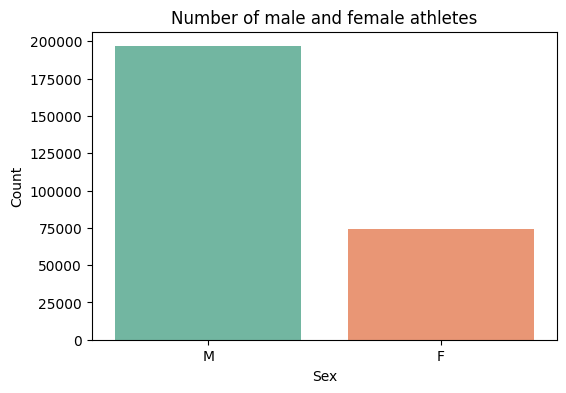

In [18]:
plt.figure(figsize=(6, 4))
sns.countplot(data=merged, x='Sex', palette='Set2')
plt.title('Number of male and female athletes')
plt.xlabel('Sex')
plt.ylabel('Count')
plt.show()

#### h - Diagram över topp 10 länder som tagit flest medaljer

C:\Users\jubel\AppData\Local\Temp\ipykernel_22972\196988685.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_10_countries.index, y=top_10_countries.values, palette='muted')


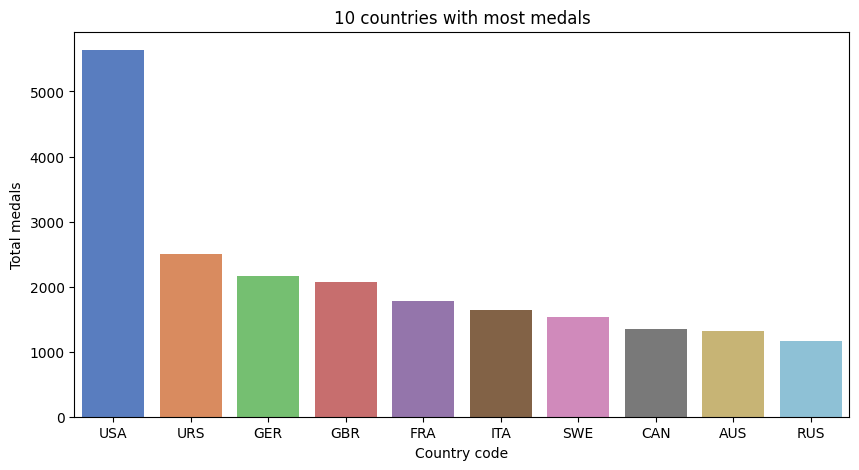

In [17]:
# filtra ut länder som INTE ha null på Medal
medals = merged.dropna(subset=['Medal'])
medals

# räkna medaljer per land
top_10_countries = medals["NOC"].value_counts().head(10)
top_10_countries

# plotta top 10 länderna
plt.figure(figsize=(10, 5))
sns.barplot(x=top_10_countries.index, y=top_10_countries.values, palette='muted')
plt.title('10 countries with most medals')
plt.xlabel('Country code')
plt.ylabel('Total medals')
plt.show()

####  i - Plotta fler intressanta saker 
Detta har vi också gjort i våra notebooks